In [113]:
import pandas as pd
import numpy as np

In [114]:
#### load water ucsd radiosone data
### test with one location
import pandas as pd
# import files
df = pd.read_csv(r"C:\Users\lisaw\OneDrive\Documents\temp\ThesisRepo\Data\radiosonde\USVAL_radiosonde.csv.gz", )

# remove strange values
df[~df.isin([-99.99, -9999]).any(axis=1)]

mean = df.groupby('Datetime')['WaterVaporDensity(kg/m^3)'].mean()
med = df.groupby('Datetime')['WaterVaporDensity(kg/m^3)'].median()
loc = df.groupby('Datetime')['Location'].first()
data = pd.concat([mean, med, loc], axis = 1, ignore_index = True)

data.columns = ['MeanWaterVaporDensity(kg/m^3)', 'MedianWaterVaporDensity(kg/m^3)', 'Location']

print (data)

                     MeanWaterVaporDensity(kg/m^3)  \
Datetime                                             
2025-02-03 20:31:00                       0.001357   
2025-02-03 23:26:00                       0.001071   
2025-02-04 02:20:00                       0.001162   
2025-02-04 21:19:00                       0.000601   
2025-02-04 23:31:00                       0.000592   
2025-02-05 02:33:00                       0.000648   
2025-02-05 20:30:00                       0.000415   
2025-02-05 20:36:00                       0.000645   
2025-02-05 23:30:00                       0.000985   
2025-02-06 02:33:00                       0.001184   
2025-02-06 23:35:00                       0.000380   
2025-02-07 02:31:00                       0.000261   
2025-02-12 20:34:00                       0.000584   
2025-02-12 23:31:00                       0.000698   
2025-02-13 02:31:00                       0.000706   
2025-02-14 20:34:00                       0.000265   
2025-02-14 23:35:00         

In [116]:
#### for loop for processing all radiosone data
from pathlib import Path
path = Path(r"C:\Users\lisaw\OneDrive\Documents\temp\ThesisRepo\Data\radiosonde")

files = list(path.glob("*.gz"))

data_list = []

for name in files:
    df = pd.read_csv(name)
    # remove strange values
    df = df[(df != -99.99) & (df != -9999)]
    mean = df.groupby('Datetime')['WaterVaporDensity(kg/m^3)'].mean()
    med = df.groupby('Datetime')['WaterVaporDensity(kg/m^3)'].median()
    # summarize data by date
    ## print out average and mean values of each date across heights
    loc = df.groupby('Datetime')['Location'].first()
    data = pd.concat([mean, med, loc], axis = 1, ignore_index = True)
    data.columns = ['MeanWaterVaporDensity(kg/m^3)', 'MedianWaterVaporDensity(kg/m^3)', 'Location']
    data_list.append(data)

combined_data = pd.concat(data_list) # combine into one intermediate file

combined_data['Datetime'] = pd.to_datetime(combined_data.index, errors = 'coerce')
combined_data['Date'] = combined_data['Datetime'].dt.normalize()

print(combined_data)


                     MeanWaterVaporDensity(kg/m^3)  \
Datetime                                             
2025-01-25 16:22:00                       0.001450   
2026-02-03 22:21:00                       0.002496   
2026-02-04 03:00:00                       0.002630   
2026-02-04 18:00:00                       0.001859   
2026-02-04 21:00:00                       0.002962   
...                                            ...   
2026-02-17 23:25:00                       0.000837   
2026-02-18 02:30:00                       0.001445   
2026-03-10 19:25:00                       0.001634   
2026-03-26 17:27:00                       0.001426   
2026-04-11 15:51:00                       0.000646   

                     MedianWaterVaporDensity(kg/m^3) Location  \
Datetime                                                        
2025-01-25 16:22:00                         0.001268    CAPRA   
2026-02-03 22:21:00                         0.002498    CAPRA   
2026-02-04 03:00:00                  

In [117]:
#### load spam_mjo data
spam_mjo = pd.read_csv(r"C:\Users\lisaw\OneDrive\Documents\temp\ThesisRepo\Data\Indexes\spam_mjo.csv")
spam_mjo['Date'] = pd.to_datetime(spam_mjo['Date'], errors = 'coerce').dt.normalize()
print(spam_mjo)


       Unnamed: 0       Date   SOI  PDO  AO  Year  Month  Day  Hour      PC1  \
0               0 1866-01-01 -0.62  NaN NaN  1866      1    1   NaN      NaN   
1               1 1866-02-01 -0.12  NaN NaN  1866      2    1   NaN      NaN   
2               2 1866-03-01 -0.62  NaN NaN  1866      3    1   NaN      NaN   
3               3 1866-04-01 -0.65  NaN NaN  1866      4    1   NaN      NaN   
4               4 1866-05-01  0.04  NaN NaN  1866      5    1   NaN      NaN   
...           ...        ...   ...  ...  ..   ...    ...  ...   ...      ...   
14372       14372 2026-03-30   NaN  NaN NaN  2026      3   30   NaN  0.08614   
14373       14373 2026-03-31   NaN  NaN NaN  2026      3   31   NaN  0.14299   
14374       14374 2026-04-01   NaN  NaN NaN  2026      4    1   NaN  0.18278   
14375       14375 2026-04-02   NaN  NaN NaN  2026      4    2   NaN  0.15454   
14376       14376 2026-04-03   NaN  NaN NaN  2026      4    3   NaN  0.10150   

           PC2  PC1_2_Amp  MJO_Phase  


In [168]:
#### match radiosone data to index data by date
mjo_watervapor = pd.merge(
    combined_data,
    spam_mjo,
    on='Date',
    how='inner'   # or 'outer' if you want all dates
)

mjo_watervapor_cleaned = mjo_watervapor.drop_duplicates(subset = ['Date', 'Location']) # clean data to include unique dates and location

print(mjo_watervapor_cleaned)

     MeanWaterVaporDensity(kg/m^3)  MedianWaterVaporDensity(kg/m^3) Location  \
0                         0.001450                         0.001268    CAPRA   
1                         0.002496                         0.002498    CAPRA   
2                         0.002630                         0.002548    CAPRA   
5                         0.004965                         0.004939    CAPRA   
7                         0.001506                         0.000851    CAPRA   
..                             ...                              ...      ...   
507                       0.000455                         0.000060    USVAL   
510                       0.000891                         0.000049    USVAL   
513                       0.001445                         0.000249    USVAL   
514                       0.001634                         0.000161    USVAL   
515                       0.001426                         0.000045    USVAL   

               Datetime       Date  Unn

In [169]:
#### mjo_watervapor to csv

mjo_watervapor_cleaned.to_csv(r"C:\Users\lisaw\OneDrive\Documents\temp\ThesisRepo\Data\intermediate\mjo_watervapor_cleaned.csv")



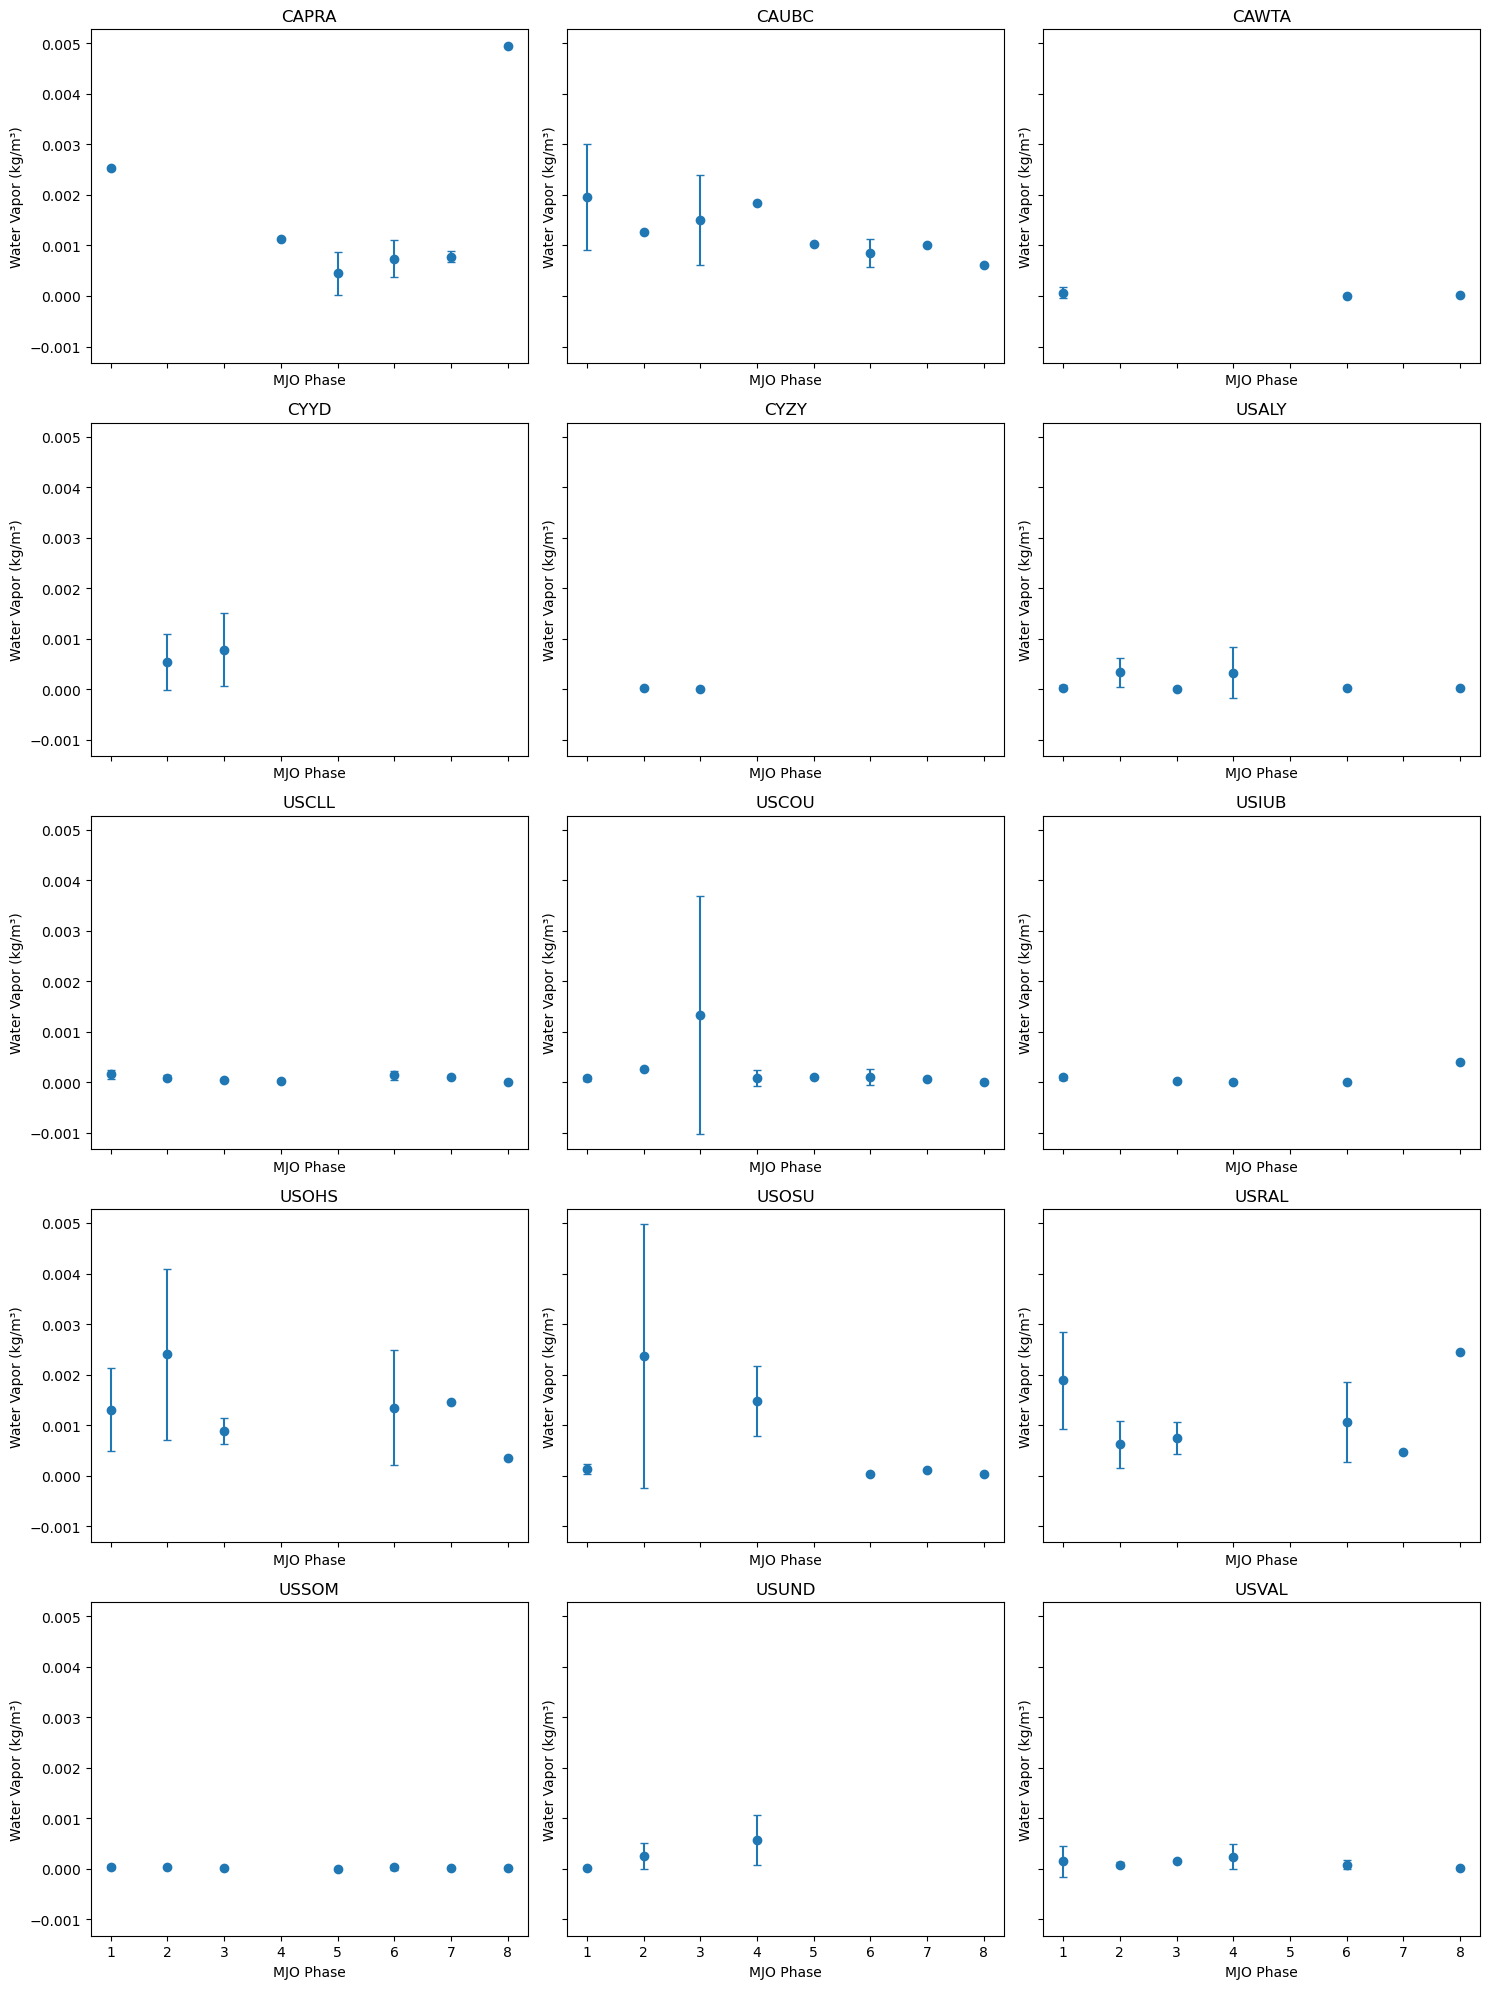

In [182]:
#### heat map
# %pip install seaborn

summary = mjo_watervapor_cleaned.groupby(['Location', 'MJO_Phase'])['MedianWaterVaporDensity(kg/m^3)'].agg(
    mean='mean',
    std='std',
    count='count'
).reset_index()

summary['sem'] = summary['std'] / summary['count']**0.5

import matplotlib.pyplot as plt
import numpy as np

locations = summary['Location'].unique()
n_locs = len(locations)

ncols = 3
nrows = int(np.ceil(n_locs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, loc in enumerate(locations):
    ax = axes[i]
    data = summary[summary['Location'] == loc]
    
    ax.errorbar(
        data['MJO_Phase'],
        data['mean'],
        yerr=data['std'],   # or std
        fmt='o',            # scatter ONLY (no line)
        capsize=3
    )
    
    ax.set_title(loc)
    ax.set_xlabel('MJO Phase')
    ax.set_ylabel('Water Vapor (kg/m³)')
    ax.set_xticks(range(1, 9))

# remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [198]:
# avg transport by date

date_loc = (
    mjo_watervapor_cleaned
    .groupby('Date')
    .agg(
        MeanWaterVaporDensity=('MedianWaterVaporDensity(kg/m^3)', 'mean'),
        count=('MedianWaterVaporDensity(kg/m^3)', 'count'),
        MJO_Phase=('MJO_Phase', 'first')
    )
    .reset_index()
    .sort_values('Date')
)

print(date_loc)

         Date  MeanWaterVaporDensity  count  MJO_Phase
0  2021-07-12               0.000007      1        5.0
1  2025-01-25               0.001268      1        6.0
2  2025-01-27               0.001022      1        5.0
3  2025-01-29               0.000106      1        5.0
4  2025-02-03               0.000589      4        4.0
5  2025-02-04               0.000614      5        4.0
6  2025-02-05               0.000590      5        4.0
7  2025-02-06               0.000352      6        4.0
8  2025-02-07               0.000333      6        4.0
9  2025-02-12               0.000181      5        2.0
10 2025-02-13               0.000281      6        2.0
11 2025-02-14               0.000279      4        2.0
12 2025-02-15               0.002318      2        2.0
13 2025-02-16               0.000667      1        2.0
14 2025-02-18               0.000136      1        2.0
15 2025-02-22               0.003301      1        2.0
16 2025-02-23               0.006902      1        2.0
17 2025-07

In [ ]:
#### open air?!

In [209]:
#### vapor transpor group by phase
date_loc.groupby('MJO_Phase')['MeanWaterVaporDensity'].agg(mean = 'mean', 
                                                           std = 'std',
                                                           count = 'count')

,mean,std,count
MJO_Phase,,,
1.0,0.000284,0.000248,15
2.0,0.001108,0.001767,19
3.0,0.000597,0.000412,7
4.0,0.000684,0.000568,8
5.0,0.000406,0.000451,5
6.0,0.000525,0.000364,15
7.0,0.000443,0.000300,3
8.0,0.000584,0.000263,2


In [200]:
#### statistical test - 6 and 7 vs. other phases of mjo
###  6 and 7 average of average and avreage of medium vs. others averwage of average and average of medium
date_loc[
    (date_loc['MJO_Phase'] == 7) |
    (date_loc['MJO_Phase'] == 6)
]['MeanWaterVaporDensity'].agg(
    mean='mean',
    count='count'
)

mean      0.000511
count    18.000000
Name: MeanWaterVaporDensity, dtype: float64

In [202]:
date_loc[
    (date_loc['MJO_Phase'] != 7) &
    (date_loc['MJO_Phase'] != 6)
]['MeanWaterVaporDensity'].agg(
    mean='mean',
    count='count'
)

mean      0.000681
count    56.000000
Name: MeanWaterVaporDensity, dtype: float64

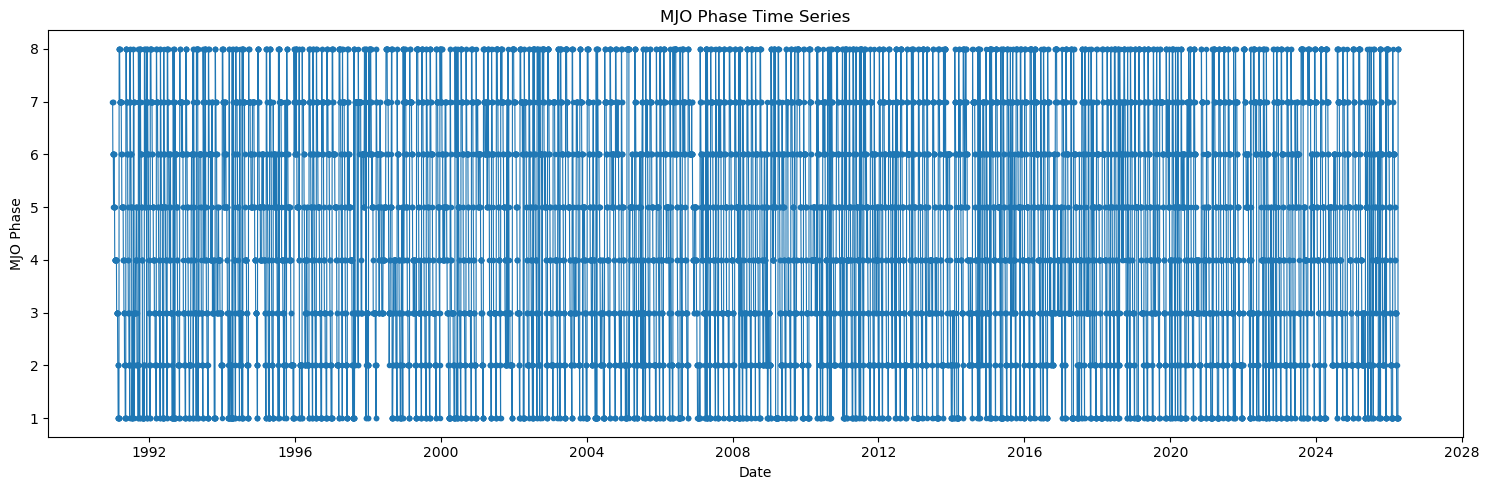

In [184]:
#### plot mjo time series
import matplotlib.pyplot as plt

df = spam_mjo.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

plt.figure(figsize=(15, 5))

plt.plot(df['Date'], df['MJO_Phase'], marker='.', linestyle='-', linewidth=0.8)

plt.yticks(range(1, 9))
plt.xlabel('Date')
plt.ylabel('MJO Phase')
plt.title('MJO Phase Time Series')

plt.tight_layout()
plt.show()


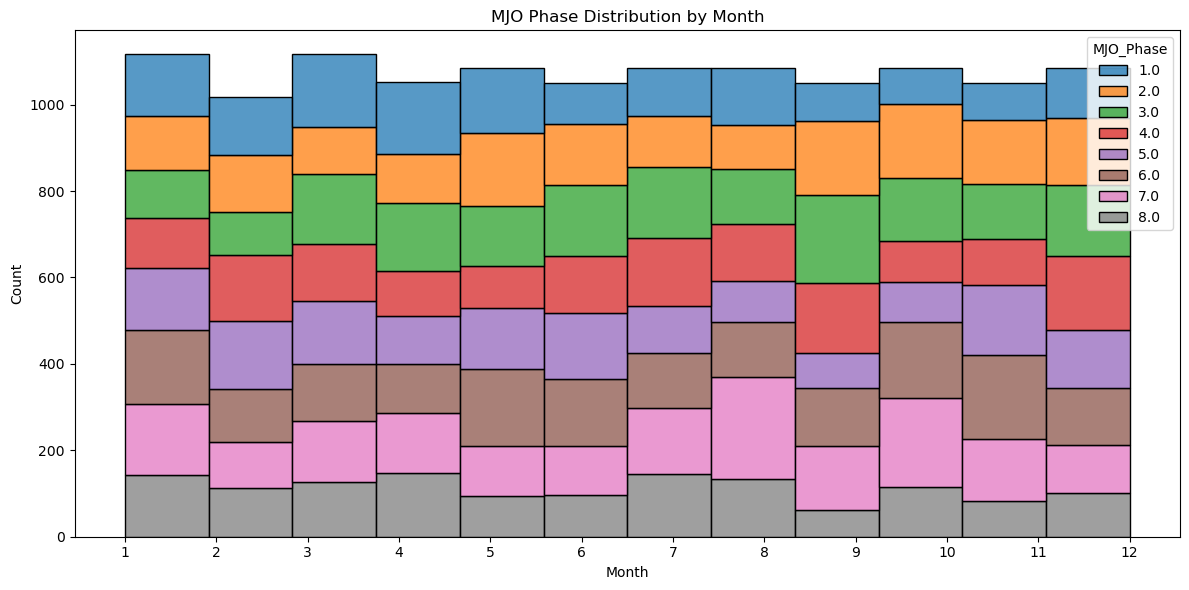

In [186]:
import seaborn as sns

df = spam_mjo.copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='Month',
    hue='MJO_Phase',
    multiple='stack',
    bins=12,
    palette='tab10'
)

plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('MJO Phase Distribution by Month')
plt.tight_layout()
plt.show()

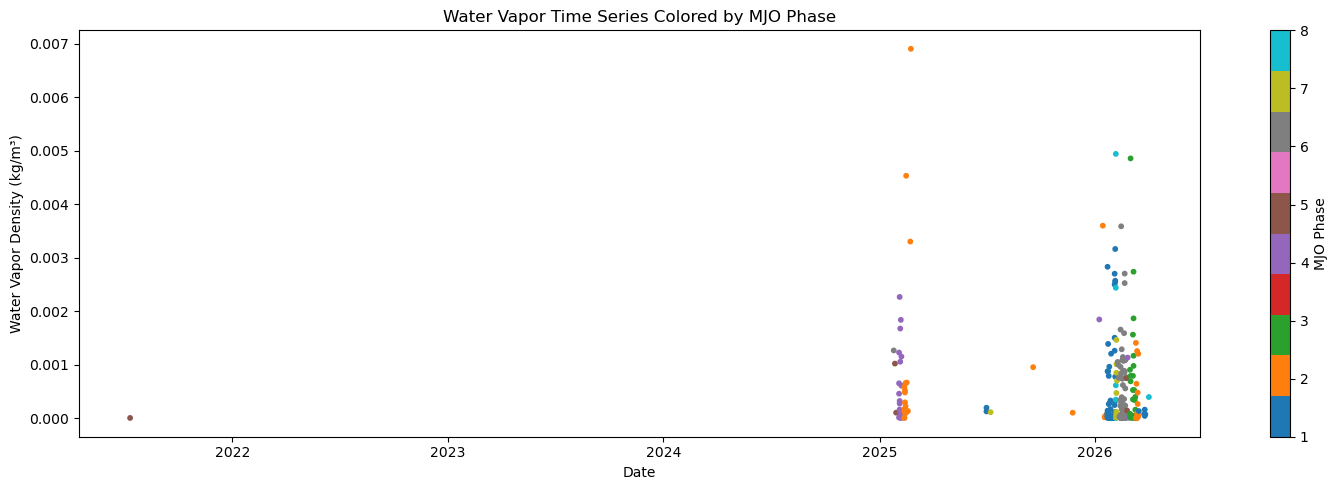

In [185]:
import matplotlib.pyplot as plt

df = mjo_watervapor_cleaned.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

plt.figure(figsize=(15, 5))

scatter = plt.scatter(
    df['Date'],
    df['MedianWaterVaporDensity(kg/m^3)'],
    c=df['MJO_Phase'],
    cmap='tab10',
    s=10
)

plt.xlabel('Date')
plt.ylabel('Water Vapor Density (kg/m³)')
plt.title('Water Vapor Time Series Colored by MJO Phase')

cbar = plt.colorbar(scatter)
cbar.set_label('MJO Phase')

plt.tight_layout()
plt.show()

In [ ]:
#### do it by location??

In [ ]:
#### ENSO and moisture graph and r square

In [ ]:
#### PDO and moisture graph and r square

In [ ]:
#### AO and moisture gragh and r square